In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration to display graphs in the notebook
%matplotlib inline
plt.style.use('ggplot')
sns.set(style='whitegrid')


# <b><span style='color:#F1A424'>|</span> Data Loading and Initial Exploration <span style='color:#F1A424'>|</span></b>
Load your dataset and get a first look at its structure and contents.


In [2]:
# Load the dataset
df = pd.read_csv('Datasets/Tabular/Binary_pred/csv/dataset1_with_target.csv')

# Display basic information
print("Table shape:", df.shape)
print("Column names:", df.columns.tolist())
df.head()


Table shape: (10000, 13)
Column names: ['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_7', 'Feature_8', 'Feature_9', 'Gender', 'Education_Level', 'YTarget', 'ID']


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Gender,Education_Level,YTarget,ID
0,0.034393,-2.321017,-6.203400,-0.436913,2.927142,-2.693756,4.398990,3.561364,-1.232883,F,Bachelor,0,1
1,-0.512961,0.479420,1.269877,0.780273,1.448405,1.776383,2.641868,0.325823,1.224481,F,High School,0,2
2,2.058784,1.741284,1.783651,-2.407541,-2.701716,-5.874976,-2.597328,-0.378960,-1.032383,F,Bachelor,1,3
3,-3.927545,5.979942,0.181224,-1.308928,-0.707485,1.461797,-0.181038,-0.458087,-2.004393,F,High School,0,4
4,-5.212868,-2.930797,-3.392059,2.588688,3.113553,2.064369,-3.325546,1.778318,0.073741,F,High School,0,5


# <b><span style='color:#F1A424'>|</span> Categorical Data Encoding <span style='color:#F1A424'>|</span></b>
Convert categorical variables into numeric codes for analysis.


In [3]:
# Transform categorical columns to numerical
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for col in df.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
print("\nDataFrame after categorical encoding:")
df.head()



DataFrame after categorical encoding:


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Gender,Education_Level,YTarget,ID
0,0.034393,-2.321017,-6.203400,-0.436913,2.927142,-2.693756,4.398990,3.561364,-1.232883,0,0,0,1
1,-0.512961,0.479420,1.269877,0.780273,1.448405,1.776383,2.641868,0.325823,1.224481,0,1,0,2
2,2.058784,1.741284,1.783651,-2.407541,-2.701716,-5.874976,-2.597328,-0.378960,-1.032383,0,0,1,3
3,-3.927545,5.979942,0.181224,-1.308928,-0.707485,1.461797,-0.181038,-0.458087,-2.004393,0,1,0,4
4,-5.212868,-2.930797,-3.392059,2.588688,3.113553,2.064369,-3.325546,1.778318,0.073741,0,1,0,5


# <b><span style='color:#F1A424'>|</span> Correlation Analysis <span style='color:#F1A424'>|</span></b>
Analyze the relationships between features to inform feature selection.
We are using the absolute value of the correlation matrix to get insight on the magnitude of the correlation between the features, as the sign of the correlation is not important for the feature selection step.


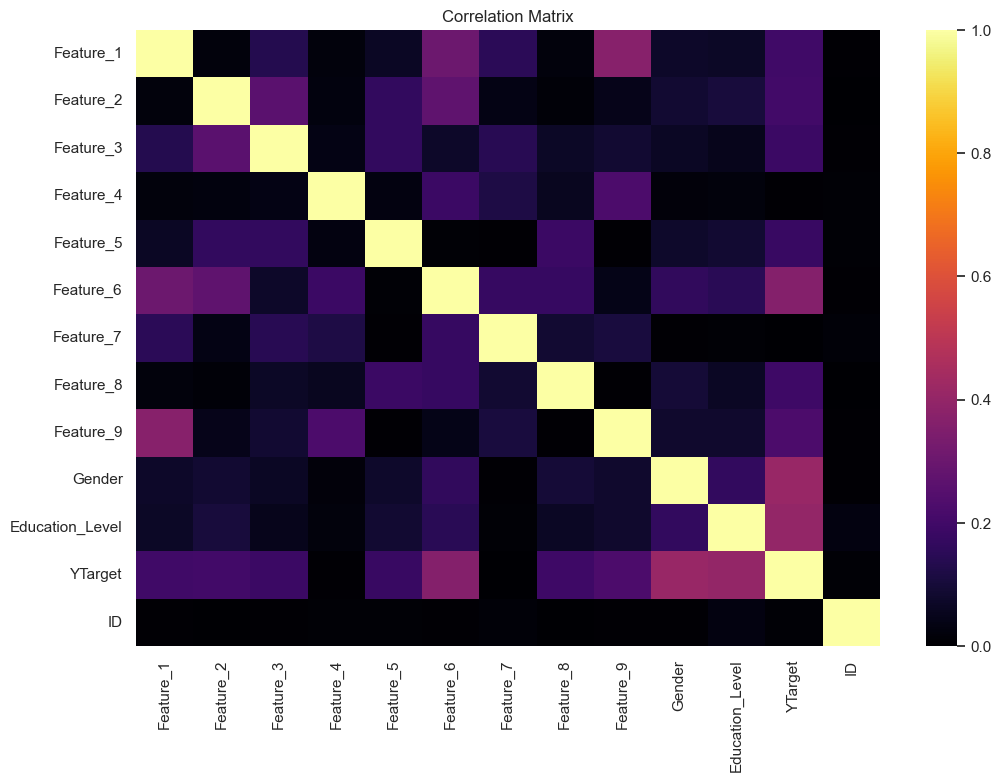

In [4]:
# Display correlation matrix
corr_matrix = df.corr().abs()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='inferno', vmin=0, vmax=1)
plt.title('Correlation Matrix')
plt.show()


In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from torch.utils.data import TensorDataset, DataLoader


# <b><span style='color:#F1A424'>|</span> Data Preparation and Splitting <span style='color:#F1A424'>|</span></b>
Splitting the data into training and test sets, and normalizing the features.


In [6]:
# Split and preprocess the data
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['YTarget']), df['YTarget'], test_size=0.2, random_state=42)

# Scale features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# <b><span style='color:#F1A424'>|</span> XGBoost Model Setup <span style='color:#F1A424'>|</span></b>
Initialization and configuration of the XGBoost model for multiclass classification.


In [7]:
import xgboost as xgb

# Create DMatrix for XGBoost
dtrain = xgb.DMatrix(X_train_scaled, label=y_train)
dtest = xgb.DMatrix(X_test_scaled, label=y_test)

# Set parameters for XGBoost
params = {
    'objective': 'multi:softmax',
    'num_class': '2',
    'max_depth': 6,
    'eta': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 1,
    'eval_metric': 'mlogloss'
}


# <b><span style='color:#F1A424'>|</span> XGBoost Training & Evaluation <span style='color:#F1A424'>|</span></b>
Training the XGBoost model with early stopping and evaluating its performance.


In [8]:
# Train the model with early stopping
num_rounds = 1000
eval_list = [(dtrain, 'train'), (dtest, 'eval')]
model = xgb.train(params, dtrain, num_rounds, eval_list,
               early_stopping_rounds=20, verbose_eval=100)

# Make predictions and evaluate
y_pred = model.predict(dtest)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


[0]	train-mlogloss:0.62536	eval-mlogloss:0.62542


[100]	train-mlogloss:0.06801	eval-mlogloss:0.11522


/Users/eliottvalette/Library/Mobile Documents/com~apple~CloudDocs/Documents/Codage /NoteBook Maker/.venv/lib/python3.10/site-packages/xgboost/core.py:726: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[200]	train-mlogloss:0.02622	eval-mlogloss:0.10686


[271]	train-mlogloss:0.01483	eval-mlogloss:0.10560


Accuracy: 0.9515

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       962
           1       0.96      0.95      0.95      1038

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



# <b><span style='color:#F1A424'>|</span> XGBoost Visualization <span style='color:#F1A424'>|</span></b>
Confusion matrix and feature importance for the XGBoost model.


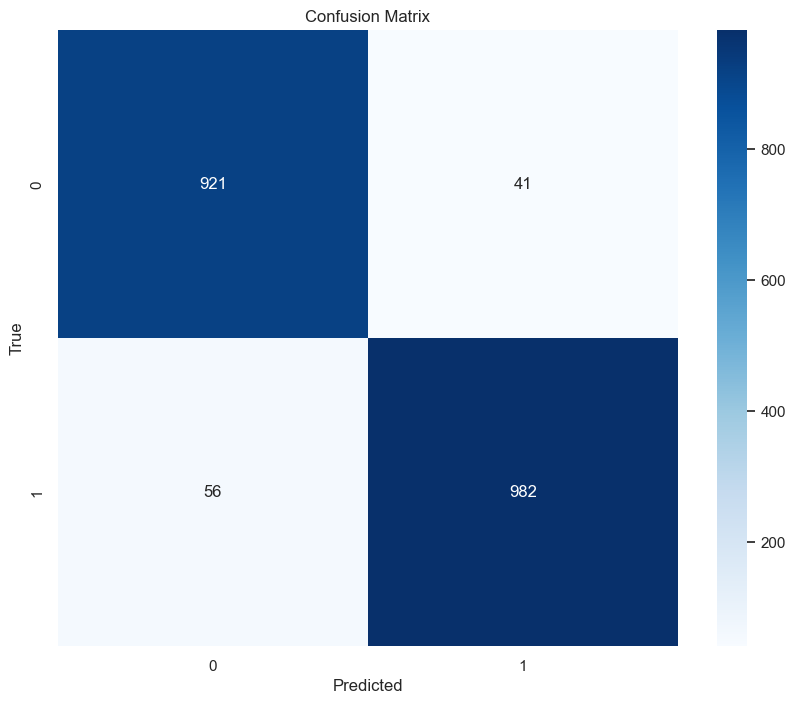

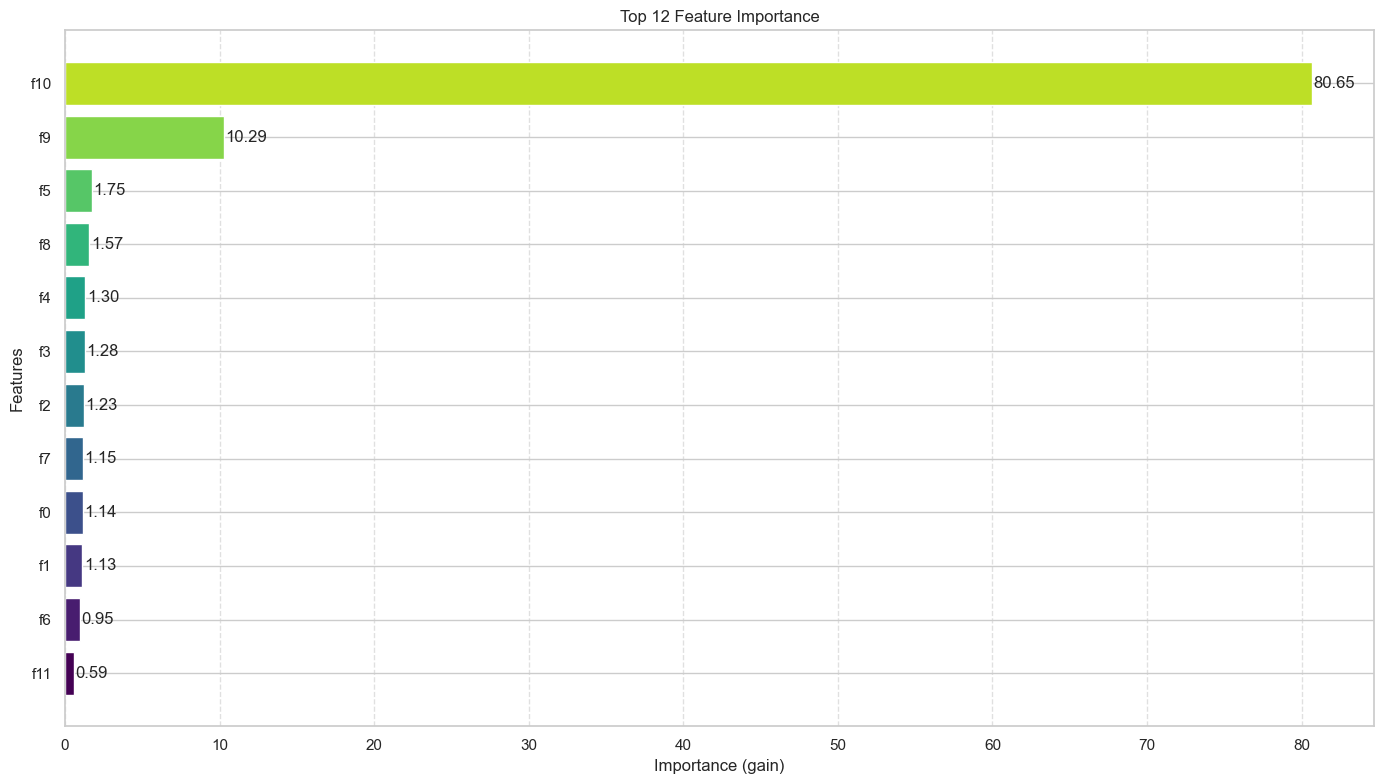

In [9]:
# Plot confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Feature importance visualization
plt.figure(figsize=(14, 8))
importance = model.get_score(importance_type='gain')
features = list(importance.keys())
scores = list(importance.values())
indices = np.argsort(scores)[-20:]

colors = plt.cm.viridis(np.linspace(0, 0.9, len(indices)))
plt.barh(range(len(indices)), [scores[i] for i in indices], color=colors)
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Importance (gain)')
plt.ylabel('Features')
plt.title(f'Top {min(20, len(features))} Feature Importance')
plt.grid(axis='x', linestyle='--', alpha=0.6)

for i, v in enumerate([scores[idx] for idx in indices]):
    plt.text(v + 0.1, i, f"{v:.2f}", va='center')

plt.tight_layout()
plt.show()
